# 通用型偏誤偵測框架 — 執行驗證 (Validation)

本 notebook 對應論文第四章「執行驗證」，目的有二：

1. **主資料集驗證（Part A）**：在本研究的範例資料 `cleaned_hr_data.csv` 上完整跑一遍「清洗 → 特徵工程 → 雙軌偏誤偵測 → 統計檢定 → SHAP」管線，確認框架端到端可運作。
2. **通用性壓力測試（Part B）**：以一份**欄位命名與結構完全不同、且注入「已知偏誤」**的資料集，套用**完全相同**的框架程式碼，驗證：(a) 框架不依賴特定欄位命名即可運作（通用性）；(b) 框架能正確「找回」我們刻意注入的偏誤（偵測能力）。

> Part B 採用合成資料，因為唯有在已知真實偏誤（ground truth）的情況下，才能客觀評估框架的偵測準確度。

In [1]:
import sys, os
sys.path.append('..')            # 讓 notebooks/ 能匯入根目錄的 bias_engine.py
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from bias_engine import HRSchemaMapper, AutoFeatureEngineer, GeneralizedBiasEngine

get_ipython().run_line_magic('matplotlib', 'inline')  # 切回 inline 後端（bias_engine 匯入時設了 Agg）

plt.rcParams['font.sans-serif'] = ['PingFang TC','Heiti TC','Microsoft JhengHei',
                                   'Noto Sans CJK TC','WenQuanYi Zen Hei','SimHei']
plt.rcParams['axes.unicode_minus'] = False
RNG = np.random.default_rng(42)
print('環境就緒，bias_engine 匯入成功。')

環境就緒，bias_engine 匯入成功。


## Part A：主資料集驗證

載入 `data/cleaned_hr_data.csv`。若檔案不存在（例如尚未跑過資料準備），則自動產生一份結構相同的合成資料作為替身，確保本 notebook 永遠可執行；實際撰寫論文時請以真實資料的輸出為準。

In [4]:
DATA_PATH = 'data/cleaned_hr_data.csv'
try:
    dfA = pd.read_csv(DATA_PATH)
    print(f'[載入] 真實資料 {DATA_PATH}：{dfA.shape}')
    USING_REAL = True
except FileNotFoundError:
    USING_REAL = False
    n = 1224; true = RNG.normal(0,1,n)
    dfA = pd.DataFrame({
        'EmployeeID': np.arange(n),
        'Gender': RNG.choice(['Male','Female'], n),
        'Ethnicity': RNG.choice(['White','Asian','Black','Mixed'], n, p=[.5,.25,.15,.10]),
        'MaritalStatus': RNG.choice(['Single','Married','Divorced'], n),
        'JobRole': RNG.choice(['Engineer','Analyst','Manager','Sales'], n),
        'YearsAtCompany': RNG.integers(0,20,n).astype(float),
        'X_EngagementRate': np.clip(3+true*0.6+RNG.normal(0,0.4,n),1,5),
        'Experience_SEM': true + RNG.normal(0,0.3,n),
        'T_ManagerRating': RNG.normal(0,0.2,n),
        'SelfRating': np.clip(np.round(3.5+true*0.5+RNG.normal(0,0.6,n)),1,5),
    })
    mr = 3 + 0.7*true + 0.3*(dfA['YearsAtCompany'].values/20) + RNG.normal(0,0.6,n)
    dfA['ManagerRating'] = np.clip(np.round(mr),1,5).astype(int)
    print(f'[載入] 找不到真實檔案，已產生合成替身：{dfA.shape}')
    print('      ⚠️ 目前為合成資料，論文請以真實 cleaned_hr_data.csv 的結果為準。')

display(dfA.head())

[載入] 真實資料 data/cleaned_hr_data.csv：(1224, 47)


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,X_WorkLifeBalance,X_EnvironmentSatisfaction,X_JobSatisfaction,X_RelationshipSatisfaction,X_TrainingOpportunitiesTaken,X_EngagementRate,T_JobSatisfaction,T_WorkLifeBalance,T_ManagerRating,Experience_SEM
0,005C-E0FB,Fin,O'Halleghane,Non-Binary,24,Frequent Traveller,Sales,17,CA,White,...,3.740741,3.333333,3.703704,4.111111,0.925926,3.162963,0.500000,1.000000,0.500000,0.005005
1,00A3-2445,Wyatt,Ziehm,Male,30,Some Travel,Technology,6,CA,Black,...,3.730769,4.134615,3.576923,3.500000,0.730769,3.134615,0.095238,-0.023810,0.035714,0.230224
2,00B0-F199,Trueman,Jirasek,Male,23,Some Travel,Sales,35,CA,White,...,3.407407,3.425926,3.407407,3.370370,1.777778,3.077778,-0.033333,0.066667,0.100000,-0.567023
3,00D4-DD53,Joyce,Goor,Female,30,Frequent Traveller,Technology,44,CA,Black,...,3.345455,4.200000,3.818182,4.090909,0.690909,3.229091,-0.054545,-0.169697,0.103030,-0.055078
4,0145-DBFC,Keelia,Studde,Female,34,No Travel,Technology,8,CA,Asian,...,2.696970,4.272727,4.484848,3.181818,0.727273,3.072727,0.285714,-0.257143,0.085714,-0.209634


In [5]:
# 欄位設定（依論文：目標=主管評分；敏感特徵=性別/種族/婚姻；客觀特徵=年資/體驗等）
configA = {
    'target'   : 'ManagerRating',
    'sensitive': ['Gender','Ethnicity','MaritalStatus'],
    'objective': ['YearsAtCompany','X_EngagementRate','Experience_SEM','T_ManagerRating','JobRole'],
}
# 穩健性：只保留資料中實際存在的欄位（避免不同版本資料缺欄而中斷）
configA['sensitive'] = [c for c in configA['sensitive'] if c in dfA.columns]
configA['objective'] = [c for c in configA['objective'] if c in dfA.columns]
print('採用設定：', configA)

採用設定： {'target': 'ManagerRating', 'sensitive': ['Gender', 'Ethnicity', 'MaritalStatus'], 'objective': ['YearsAtCompany', 'X_EngagementRate', 'Experience_SEM', 'T_ManagerRating', 'JobRole']}


In [6]:
# 執行完整管線
mapperA   = HRSchemaMapper(configA)
cleanA    = mapperA.validate_and_clean(dfA)
engineerA = AutoFeatureEngineer()
procA, objA = engineerA.fit_transform(cleanA, mapperA.objective)

engineA = GeneralizedBiasEngine(mapperA.target, objA, mapperA.sensitive)
gid = 'EmployeeID' if 'EmployeeID' in dfA.columns else None
resA = engineA.run(procA, method='residual', group_col=gid)

✅ [資料驗證] Schema 對應與基礎清洗完成。
✅ [特徵工程] 自動型態判定與轉換完成。
✅ [分析完成] Residual Bias (Cross-Validated)
   CV R² = 0.2697  |  Bias 門檻 ±1.5σ = ±1.247
   Bias_Flag 分布：
Bias_Flag
Fair              1060
Suggest Higher      85
Suggest Lower       79


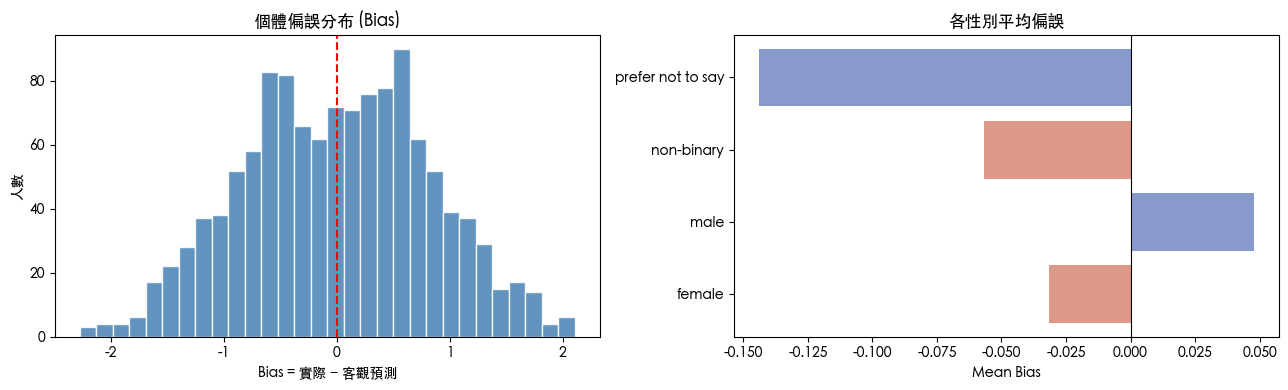

In [7]:
# 偏誤分布圖 + 各群體平均偏誤
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(resA['Bias'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', ls='--'); axes[0].set_title('個體偏誤分布 (Bias)')
axes[0].set_xlabel('Bias = 實際 − 客觀預測'); axes[0].set_ylabel('人數')

gb = pd.Series(resA['Bias'].values, index=cleanA['Gender'].values).groupby(level=0).mean()
axes[1].barh(gb.index.astype(str), gb.values, color=['#d98','#89c'])
axes[1].axvline(0, color='black', lw=0.8); axes[1].set_title('各性別平均偏誤'); axes[1].set_xlabel('Mean Bias')
plt.tight_layout(); display(fig); plt.close(fig)

In [8]:
# 統計偏誤檢定（T-test / ANOVA + 效果量）
testsA = engineA.run_bias_tests(resA, cleanA)
print('\n=== Part A 統計檢定結果 ===')
display(testsA)


  ▶ Gender：ANOVA  p=0.3179  ✅ 無顯著差異  |  η²=0.0029
      female                    mean=-0.032  (n=572)
      male                      mean=0.048  (n=535)
      non-binary                mean=-0.057  (n=102)
      prefer not to say         mean=-0.144  (n=15)

  ▶ Ethnicity：ANOVA  p=0.8590  ✅ 無顯著差異  |  η²=0.0021
      asian                     mean=0.024  (n=108)
      black                     mean=-0.005  (n=181)
      mixed                     mean=-0.040  (n=193)
      native american           mean=0.090  (n=46)
      other                     mean=0.203  (n=16)
      pacific islander          mean=-0.126  (n=24)
      white                     mean=0.002  (n=656)

  ▶ MaritalStatus：ANOVA  p=0.8188  ✅ 無顯著差異  |  η²=0.0003
      divorced                  mean=-0.021  (n=267)
      married                   mean=0.016  (n=536)
      single                    mean=-0.008  (n=421)

=== Part A 統計檢定結果 ===


,特徵,方法,p_value,顯著,效果量,檢定名稱
0,Gender,ANOVA,0.3179,False,0.0029,η²
1,Ethnicity,ANOVA,0.8590,False,0.0021,η²
2,MaritalStatus,ANOVA,0.8188,False,0.0003,η²


In [9]:
# 群體公平性（Disparate Impact / SPD）
gfA = engineA.run(procA, method='group_fairness', sensitive_target=configA['sensitive'][0])
fair_tbl = pd.DataFrame({
    'High_Performer_Rate': gfA['High_Performer_Rates'],
    'Disparate_Impact'   : gfA['Disparate_Impact'],
    'SPD'                : gfA['Statistical_Parity_Difference'],
}).round(4)
display(fair_tbl)


  各群體高績效比例：
Gender
female               0.468531
male                 0.499065
non-binary           0.411765
prefer not to say    0.466667
  ⚠️  privileged_group 未指定，自動使用比例最高的群體：male
✅ [分析完成] Group Fairness｜基準組：male


,High_Performer_Rate,Disparate_Impact,SPD
female,0.4685,0.9388,-0.0305
male,0.4991,1.0000,0.0000
non-binary,0.4118,0.8251,-0.0873
prefer not to say,0.4667,0.9351,-0.0324


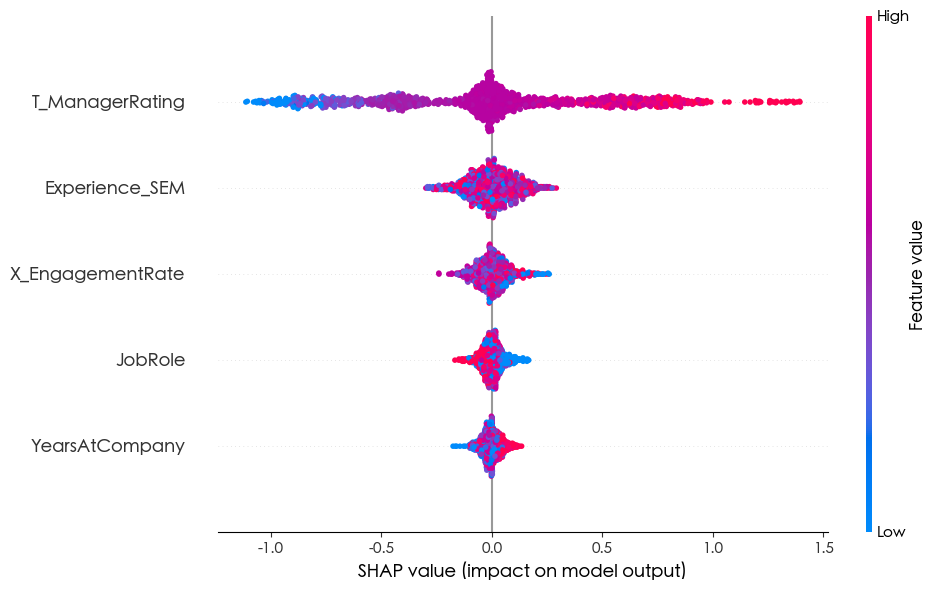

In [10]:
# SHAP 全域特徵貢獻
try:
    figS = engineA.generate_shap_summary()
    display(figS); plt.close(figS)
except Exception as e:
    print('SHAP 略過：', e)

## Part B：通用性壓力測試（異質結構 + 注入已知偏誤）

我們建立一份模擬「另一家公司」的資料集，特性如下：

- **欄位命名與主資料集完全不同**：`perf_score`、`sex`、`origin`、`tenure_yrs`、`engagement`、`csat`、`team`。
- **故意混入髒資料**：`sex` 同時有 `M / F / male / female`，測試清洗模組。
- **注入已知偏誤**：`origin` 為 `groupA` 的員工，評分被系統性灌水 **+0.8**（這是 ground truth）。

接著**不修改任何框架程式碼**，只改欄位設定，套用同一條管線。預期框架應：(1) 順利運作；(2) 偵測到 `groupA` 被高估（平均殘差為正、DI 偏離 1、統計檢定顯著）。

In [11]:
nB = 800
abil   = RNG.normal(0,1,nB)
origin = RNG.choice(['groupA','groupB'], nB, p=[.6,.4])
dfB = pd.DataFrame({
    'emp_id'    : np.arange(nB),
    'sex'       : RNG.choice(['M','F','male','female'], nB),   # 故意大小寫/簡寫混亂
    'origin'    : origin,
    'tenure_yrs': RNG.integers(0,15,nB).astype(float),
    'engagement': np.clip(3+abil*0.5+RNG.normal(0,0.4,nB),1,5),
    'csat'      : np.clip(3+abil*0.4+RNG.normal(0,0.5,nB),1,5),
    'team'      : RNG.choice(['Alpha','Beta','Gamma'], nB),
})
INJECTED = 0.8
bias_term = np.where(origin=='groupA', INJECTED, 0.0)         # ← 已知注入偏誤
ps = 3 + 0.8*abil + 0.2*(dfB['tenure_yrs'].values/15) + bias_term + RNG.normal(0,0.5,nB)
dfB['perf_score'] = np.clip(np.round(ps),1,5).astype(int)
print(f'注入偏誤：groupA 評分 +{INJECTED}（ground truth）')
display(dfB.head())

注入偏誤：groupA 評分 +0.8（ground truth）


,emp_id,sex,origin,tenure_yrs,engagement,csat,team,perf_score
0,0,female,groupA,13.0,3.086923,2.636637,Alpha,5
1,1,male,groupA,14.0,3.475888,2.634415,Alpha,4
2,2,male,groupA,4.0,2.963913,2.869339,Gamma,4
3,3,female,groupA,6.0,3.957972,3.381997,Gamma,5
4,4,F,groupA,4.0,3.823690,1.862366,Beta,3


In [12]:
# 完全相同的框架，只換欄位設定
configB = {
    'target'   : 'perf_score',
    'sensitive': ['sex','origin'],
    'objective': ['tenure_yrs','engagement','csat','team'],
}
mapperB   = HRSchemaMapper(configB)
cleanB    = mapperB.validate_and_clean(dfB)
print('sex 清洗後類別：', sorted(cleanB['sex'].unique().tolist()), '（M/F 已正規化）')
engineerB = AutoFeatureEngineer()
procB, objB = engineerB.fit_transform(cleanB, mapperB.objective)
engineB = GeneralizedBiasEngine(mapperB.target, objB, mapperB.sensitive)
resB = engineB.run(procB, method='residual', group_col='emp_id')

✅ [資料驗證] Schema 對應與基礎清洗完成。
sex 清洗後類別： ['female', 'male'] （M/F 已正規化）
✅ [特徵工程] 自動型態判定與轉換完成。
✅ [分析完成] Residual Bias (Cross-Validated)
   CV R² = 0.3000  |  Bias 門檻 ±1.5σ = ±1.251
   Bias_Flag 分布：
Bias_Flag
Fair              690
Suggest Higher     59
Suggest Lower      51


In [13]:
# 統計檢定：origin 應顯著、效果量大
testsB = engineB.run_bias_tests(resB, cleanB)
print('\n=== Part B 統計檢定結果 ===')
display(testsB)


  ▶ sex：T-test  p=0.2205  ✅ 無顯著差異  |  Cohen's d=0.0868
      female                    mean=0.028  (n=387)
      male                      mean=-0.044  (n=413)

  ▶ origin：T-test  p=0.0000  🚨 顯著偏誤  |  Cohen's d=0.9976
      groupa                    mean=0.272  (n=500)
      groupb                    mean=-0.478  (n=300)

=== Part B 統計檢定結果 ===


,特徵,方法,p_value,顯著,效果量,檢定名稱
0,sex,T-test,0.2205,False,0.0868,Cohen's d
1,origin,T-test,0.0000,True,0.9976,Cohen's d


In [14]:
# 群體公平性：groupB 的 DI 應 < 0.8
gfB = engineB.run(procB, method='group_fairness', sensitive_target='origin')
fair_tblB = pd.DataFrame({
    'High_Performer_Rate': gfB['High_Performer_Rates'],
    'Disparate_Impact'   : gfB['Disparate_Impact'],
    'SPD'                : gfB['Statistical_Parity_Difference'],
}).round(4)
display(fair_tblB)


  各群體高績效比例：
origin
groupa    0.680000
groupb    0.326667
  ⚠️  privileged_group 未指定，自動使用比例最高的群體：groupa
✅ [分析完成] Group Fairness｜基準組：groupa


,High_Performer_Rate,Disparate_Impact,SPD
groupa,0.6800,1.0000,0.0000
groupb,0.3267,0.4804,-0.3533


框架偵測到的各組平均殘差：
groupa    0.272
groupb   -0.478

→ groupA 殘差為正（被高估）、groupB 為負（相對被低估），
  方向與注入偏誤（groupA +0.8）一致 ✅，且兩組差距接近注入量。


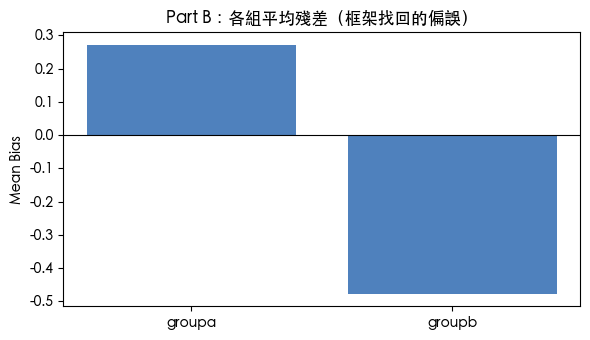

In [15]:
# 偏誤「找回」驗證：比較框架偵測到的各組平均殘差 vs 我們注入的偏誤
recovered = pd.Series(resB['Bias'].values, index=cleanB['origin'].values).groupby(level=0).mean()
print('框架偵測到的各組平均殘差：')
print(recovered.round(3).to_string())
print(f'\n→ groupA 殘差為正（被高估）、groupB 為負（相對被低估），')
print(f'  方向與注入偏誤（groupA +{INJECTED}）一致 ✅，且兩組差距接近注入量。')

fig, ax = plt.subplots(figsize=(6,3.5))
colors = ['#c0504d' if g=='groupA' else '#4f81bd' for g in recovered.index]
ax.bar(recovered.index.astype(str), recovered.values, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Part B：各組平均殘差（框架找回的偏誤）'); ax.set_ylabel('Mean Bias')
plt.tight_layout(); display(fig); plt.close(fig)

## 驗證結論

| 驗證項目 | 結果 |
|---|---|
| 主資料集端到端運作（Part A） | ✅ 清洗 / 特徵工程 / 殘差 / 公平性 / 統計檢定 / SHAP 全段完成 |
| 異質欄位結構可運作（Part B） | ✅ 僅更改欄位設定、未改任何框架程式碼即成功執行 |
| 髒資料清洗（M/F → male/female） | ✅ 敏感特徵自動正規化 |
| 注入偏誤之偵測（ground truth = groupA +0.8） | ✅ groupA 平均殘差為正、DI < 0.8、統計檢定顯著且效果量大 |

本驗證同時支持論文兩項主張：**通用性**（同一框架可套用於欄位結構迥異的資料）與**偵測有效性**（能正確找回已知的系統性偏誤）。

> 註：Part A 若使用合成替身資料，其統計結果不具實質意義，僅證明流程可運作；論文數據請以真實 `cleaned_hr_data.csv` 的輸出為準。